# Ensemble Evaluation and OpenCV Grading — Produce Quality Assessment

Evaluates the ResNet50 + MobileNetV2 ensemble on the held-out test set and implements the OpenCV-based produce quality scoring pipeline. Ensemble predictions use F1-weighted averaging derived from validation set performance. The grading pipeline produces Colour %, Size %, and Ripeness % sub-scores and assigns Grade A, B, or C per image.


## Google Drive Setup

In [1]:
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Advanced AI/advanced-ai')

print(f'Drive root : {DRIVE_ROOT}')
print(f'Exists     : {DRIVE_ROOT.exists()}')

Mounted at /content/drive
Drive root : /content/drive/MyDrive/Advanced AI/advanced-ai
Exists     : True


## Section 1   Imports and Configuration

All imports and path constants are defined here. OpenCV is installed via pip if not already available in the Colab environment.

**Ensemble weighting**: each model's contribution is proportional to its macro-F1 on the validation set — the model that performed better on unseen data contributes more. The validation set is used for weight derivation; the test set is used only for final evaluation and is never seen during weight computation.

**OpenCV grading sub-scores** (computed in Section 9):
- **Colour %**: HS histogram intersection between the image and the per-produce-type healthy reference histogram, derived from training set healthy examples.
- **Size %**: ratio of the detected bounding box area to the median healthy bounding box area for the same produce type.
- **Ripeness %**: `0.5 × Colour + 0.2 × Size + 0.3 × Quality`, where Quality reflects the ensemble's confidence in the Healthy classification.

Grade thresholds (from case study specification):
- Grade A: Colour ≥ 75%, Size ≥ 80%, Ripeness ≥ 70%
- Grade B: Colour ≥ 65%, Size ≥ 70%, Ripeness ≥ 60%
- Grade C: below Grade B on any metric

In [2]:
!pip install opencv-python-headless --quiet

import os
import json
import random
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow import keras

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# -- Paths --------------------------------------------------------------------
PROCESSED_DIR        = DRIVE_ROOT / 'data' / 'Task 2' / 'processed'
DATASET_ROOT         = DRIVE_ROOT / 'data' / 'Task 2' / 'raw' / 'Fruit And Vegetable Diseases Dataset'
MODELS_DIR           = DRIVE_ROOT / 'models'
OUTPUT_DIR           = DRIVE_ROOT / 'data' / 'Task 2' / 'ensemble'

SPLIT_LISTS_PATH     = PROCESSED_DIR / 'split_lists.json'
CLASS_INFO_PATH      = PROCESSED_DIR / 'class_info.json'

RESNET_MODEL_PATH    = MODELS_DIR / 'resnet50_brfn.h5'
MOBILENET_MODEL_PATH = MODELS_DIR / 'mobilenetv2_brfn.h5'

COLOUR_REF_PATH      = OUTPUT_DIR / 'colour_references.json'
SIZE_REF_PATH        = OUTPUT_DIR / 'size_references.json'
ENSEMBLE_METRICS_PATH = OUTPUT_DIR / 'ensemble_metrics.json'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -- Pipeline constants -------------------------------------------------------
IMG_SIZE             = 224
BATCH_SIZE           = 64
RANDOM_SEED          = 42
SMALL_CLASS_THRESHOLD = 334

# -- Grade thresholds (from case study specification) -------------------------
GRADE_A = {'colour': 75.0, 'size': 80.0, 'ripeness': 70.0}
GRADE_B = {'colour': 65.0, 'size': 70.0, 'ripeness': 60.0}

# -- OpenCV reference computation parameters ----------------------------------
# Number of HSV histogram bins per channel used for colour reference computation.
HSV_BINS = (50, 60)   # (Hue bins, Saturation bins) -- Value excluded as it
                      # correlates with lighting rather than produce quality.
# Minimum contour area as a fraction of image area to filter out noise.
MIN_CONTOUR_FRAC = 0.01

print(f'TensorFlow  : {tf.__version__}')
print(f'OpenCV      : {cv2.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')
print()
print('Paths configured:')
print(f'  Processed data   : {PROCESSED_DIR}')
print(f'  Models directory : {MODELS_DIR}')
print(f'  Ensemble output  : {OUTPUT_DIR}')
for _label, _path in [
    ('ResNet50 model', RESNET_MODEL_PATH),
    ('MobileNetV2 model', MOBILENET_MODEL_PATH),
]:
    _status = 'found' if _path.exists() else 'NOT FOUND'
    print(f'  {_label:<22} : {_status}  ({_path.name})')

TensorFlow  : 2.19.0
OpenCV      : 4.13.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Paths configured:
  Processed data   : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/processed
  Models directory : /content/drive/MyDrive/Advanced AI/advanced-ai/models
  Ensemble output  : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/ensemble
  ResNet50 model         : found  (resnet50_brfn.h5)
  MobileNetV2 model      : found  (mobilenetv2_brfn.h5)


## Section 2   Load Preprocessing Outputs and Saved Models

The split lists and class metadata from preprocessing are loaded here, identical to the training notebooks. Both trained models are loaded from Drive with `compile=False` — inference does not require the optimiser state.

In [3]:
# -- Load split lists and class metadata --------------------------------------
for _label, _path in [
    ('split_lists.json', SPLIT_LISTS_PATH),
    ('class_info.json',  CLASS_INFO_PATH),
]:
    if not _path.exists():
        raise FileNotFoundError(f'Required file not found: {_path}')

with open(SPLIT_LISTS_PATH, 'r', encoding='utf-8') as fh:
    split_lists = json.load(fh)

with open(CLASS_INFO_PATH, 'r', encoding='utf-8') as fh:
    class_info = json.load(fh)

class_names    = class_info['class_names']      # sorted list of 28 class names
class_to_index = class_info['class_to_index']   # class name -> integer index
small_classes  = class_info['small_classes']    # 8 small class names
image_counts   = class_info['image_counts']     # class name -> total image count
num_classes    = len(class_names)

def _samples_from_split(split_key):
    return [
        (s['filepath'], class_to_index[s['label']])
        for s in split_lists[split_key]
    ]

train_samples = _samples_from_split('train')
val_samples   = _samples_from_split('val')
test_samples  = _samples_from_split('test')

# Build a mapping from integer class index to produce type and quality label.
# Used by the OpenCV grading pipeline to identify produce type from prediction.
index_to_class   = {v: k for k, v in class_to_index.items()}
produce_types    = sorted({c.split('__')[0] for c in class_names})

def class_name_to_produce(class_name):
    """Extract produce type string from a class name, e.g. Apple__Healthy -> Apple."""
    return class_name.split('__')[0]

def class_name_to_quality(class_name):
    """Extract quality label from a class name, e.g. Apple__Healthy -> Healthy."""
    return class_name.split('__')[1]

print(f'Classes       : {num_classes}')
print(f'Train samples : {len(train_samples):,}')
print(f'Val samples   : {len(val_samples):,}')
print(f'Test samples  : {len(test_samples):,}')
print(f'Produce types : {len(produce_types)}  ({produce_types})')

# -- Load trained models ------------------------------------------------------
print()
print(f'Loading ResNet50 from {RESNET_MODEL_PATH}...')
resnet_model = keras.models.load_model(str(RESNET_MODEL_PATH), compile=False)
print('ResNet50 loaded.')

print(f'Loading MobileNetV2 from {MOBILENET_MODEL_PATH}...')
mobilenet_model = keras.models.load_model(str(MOBILENET_MODEL_PATH), compile=False)
print('MobileNetV2 loaded.')

Classes       : 28
Train samples : 20,503
Val samples   : 4,394
Test samples  : 4,394
Produce types : 14  (['Apple', 'Banana', 'Bellpepper', 'Carrot', 'Cucumber', 'Grape', 'Guava', 'Jujube', 'Mango', 'Orange', 'Pomegranate', 'Potato', 'Strawberry', 'Tomato'])

Loading ResNet50 from /content/drive/MyDrive/Advanced AI/advanced-ai/models/resnet50_brfn.h5...
ResNet50 loaded.
Loading MobileNetV2 from /content/drive/MyDrive/Advanced AI/advanced-ai/models/mobilenetv2_brfn.h5...
MobileNetV2 loaded.


## Section 3   Build tf.data Pipelines

Two separate data loading functions are defined — one applying ResNet50 caffe-style normalisation and one applying MobileNetV2 [-1, 1] normalisation — because the two models require different normalised inputs and cannot share a single dataset. Both use identical PIL-based decoding, resize, and centre-crop logic from the training notebooks. PIL is used rather than `tf.image.decode_image` because the dataset contains `.webp` files which the TF decoder does not support.

In [4]:
def _build_pipeline(samples, preprocess_fn):
    """Build a tf.data inference pipeline for a given normalisation function.

    Parameters
    ----------
    samples : list of (str, int)
        File path and integer class label pairs.
    preprocess_fn : callable
        One of tf.keras.applications.resnet50.preprocess_input or
        tf.keras.applications.mobilenet_v2.preprocess_input.
    """
    _paths  = [str(s[0]) for s in samples]
    _labels = [int(s[1]) for s in samples]

    ds = tf.data.Dataset.from_tensor_slices((_paths, _labels))

    def _load_and_normalise(filepath, label):
        def _pil_decode(fp_bytes):
            import numpy as np
            from PIL import Image
            img = Image.open(fp_bytes.numpy().decode('utf-8')).convert('RGB')
            # Return uint8 to keep the cache compact; cast to float32 after the cache.
            return np.array(img, dtype=np.uint8)

        image = tf.py_function(_pil_decode, [filepath], tf.uint8)
        image.set_shape([None, None, 3])
        image = tf.cast(image, tf.float32)

        # Resize shorter edge to IMG_SIZE, then centre-crop to IMG_SIZE x IMG_SIZE.
        _shape   = tf.shape(image)
        _h, _w   = _shape[0], _shape[1]
        _min_dim = tf.minimum(_h, _w)
        _scale   = tf.cast(IMG_SIZE, tf.float32) / tf.cast(_min_dim, tf.float32)
        _new_h   = tf.cast(tf.round(tf.cast(_h, tf.float32) * _scale), tf.int32)
        _new_w   = tf.cast(tf.round(tf.cast(_w, tf.float32) * _scale), tf.int32)
        image    = tf.image.resize(image, [_new_h, _new_w])
        _off_h   = (_new_h - IMG_SIZE) // 2
        _off_w   = (_new_w - IMG_SIZE) // 2
        image    = tf.image.crop_to_bounding_box(image, _off_h, _off_w, IMG_SIZE, IMG_SIZE)
        image    = tf.ensure_shape(image, [IMG_SIZE, IMG_SIZE, 3])

        # Apply model-specific normalisation.
        image = preprocess_fn(image)

        label = tf.one_hot(label, depth=num_classes)
        return image, label

    # Inference-only pipeline: single map stage, no augmentation.
    ds = ds.map(_load_and_normalise, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


def build_resnet_dataset(samples):
    """Build a tf.data pipeline with ResNet50 caffe-style normalisation."""
    return _build_pipeline(samples, tf.keras.applications.resnet50.preprocess_input)


def build_mobilenet_dataset(samples):
    """Build a tf.data pipeline with MobileNetV2 [-1, 1] normalisation."""
    return _build_pipeline(samples, tf.keras.applications.mobilenet_v2.preprocess_input)


print('Data pipeline functions defined.')
print('ResNet50 normalisation  : caffe-style BGR mean subtraction')
print('MobileNetV2 normalisation: scale to [-1, 1]')

Data pipeline functions defined.
ResNet50 normalisation  : caffe-style BGR mean subtraction
MobileNetV2 normalisation: scale to [-1, 1]


## Section 4   Compute Ensemble Weights from Validation Set

Ensemble weights are derived from each model's macro-F1 on the validation set:

    w_resnet    = F1_resnet    / (F1_resnet + F1_mobilenet)
    w_mobilenet = F1_mobilenet / (F1_resnet + F1_mobilenet)

The weights sum to 1.0. Using the validation set (not the test set) for weight derivation prevents data leakage into the final evaluation. Both equal-weight (0.5 / 0.5) and F1-weighted variants are evaluated in Section 7.

In [5]:
print('Building validation datasets...')
val_ds_resnet    = build_resnet_dataset(val_samples)
val_ds_mobilenet = build_mobilenet_dataset(val_samples)

print('Running ResNet50 inference on validation set...')
val_probs_resnet    = resnet_model.predict(val_ds_resnet,    verbose=1)

print('Running MobileNetV2 inference on validation set...')
val_probs_mobilenet = mobilenet_model.predict(val_ds_mobilenet, verbose=1)

# Reconstruct true labels from the validation dataset.
_val_labels_onehot = np.concatenate([y.numpy() for _, y in val_ds_resnet], axis=0)
val_true_idx       = np.argmax(_val_labels_onehot, axis=1)

# Compute macro-F1 for each model on the validation set.
_rep_resnet    = classification_report(
    val_true_idx, np.argmax(val_probs_resnet,    axis=1),
    target_names=class_names, output_dict=True
)
_rep_mobilenet = classification_report(
    val_true_idx, np.argmax(val_probs_mobilenet, axis=1),
    target_names=class_names, output_dict=True
)

val_f1_resnet    = _rep_resnet['macro avg']['f1-score']
val_f1_mobilenet = _rep_mobilenet['macro avg']['f1-score']

# Derive F1-weighted ensemble weights.
_total           = val_f1_resnet + val_f1_mobilenet
W_RESNET         = val_f1_resnet    / _total
W_MOBILENET      = val_f1_mobilenet / _total

print()
print('Validation set macro-F1 scores:')
print(f'  ResNet50    : {val_f1_resnet:.4f}')
print(f'  MobileNetV2 : {val_f1_mobilenet:.4f}')
print()
print('F1-weighted ensemble weights:')
print(f'  w_resnet    = {W_RESNET:.4f}')
print(f'  w_mobilenet = {W_MOBILENET:.4f}')
print(f'  sum         = {W_RESNET + W_MOBILENET:.4f}  (should be 1.0000)')

Building validation datasets...
Running ResNet50 inference on validation set...
 4/69 ━━━━━━━━━━━━━━━━━━━━ 4:24 4s/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


69/69 ━━━━━━━━━━━━━━━━━━━━ 388s 5s/step
Running MobileNetV2 inference on validation set...
69/69 ━━━━━━━━━━━━━━━━━━━━ 76s 807ms/step

Validation set macro-F1 scores:
  ResNet50    : 0.9677
  MobileNetV2 : 0.9578

F1-weighted ensemble weights:
  w_resnet    = 0.5026
  w_mobilenet = 0.4974
  sum         = 1.0000  (should be 1.0000)


## Section 5   Optional Test Run

Verifies the ensemble pipeline and OpenCV grading on a small subset before running the full evaluation. Checks that both models produce valid softmax outputs, weighted averaging gives correctly shaped predictions, and the OpenCV colour histogram and contour detection work on real images.

Set `RUN_TEST = True` to execute. Set back to `False` before running the full pipeline.

In [8]:
RUN_TEST = True

if not RUN_TEST:
    print('Test run skipped. Set RUN_TEST = True to execute.')
else:
    print('Running pipeline test on 5 images per class (val set sample)...')

    # -- Sample a small subset ------------------------------------------------
    _by_class = {}
    for _fp, _li in val_samples:
        _by_class.setdefault(_li, []).append((_fp, _li))
    _test_samples = []
    for _li, _items in _by_class.items():
        _test_samples.extend(random.sample(_items, min(5, len(_items))))
    print(f'Test subset size: {len(_test_samples)} images')

    # -- Test ensemble inference ----------------------------------------------
    _test_ds_r = build_resnet_dataset(_test_samples)
    _test_ds_m = build_mobilenet_dataset(_test_samples)

    _probs_r = resnet_model.predict(_test_ds_r,    verbose=0)
    _probs_m = mobilenet_model.predict(_test_ds_m, verbose=0)

    # Equal-weight ensemble.
    _probs_equal   = 0.5 * _probs_r + 0.5 * _probs_m
    # F1-weighted ensemble.
    _probs_weighted = W_RESNET * _probs_r + W_MOBILENET * _probs_m

    assert _probs_equal.shape   == (len(_test_samples), num_classes), 'Shape mismatch'
    assert _probs_weighted.shape == (len(_test_samples), num_classes), 'Shape mismatch'
    assert np.allclose(_probs_equal.sum(axis=1),   1.0, atol=1e-5), 'Probs do not sum to 1'
    assert np.allclose(_probs_weighted.sum(axis=1), 1.0, atol=1e-5), 'Probs do not sum to 1'

    print(f'Ensemble output shape   : {_probs_weighted.shape}  (expected ({len(_test_samples)}, {num_classes}))')
    print(f'Probability sums (first 3): {_probs_weighted[:3].sum(axis=1).round(5)}')

    # -- Test OpenCV pipeline on 3 sample images ------------------------------
    print()
    print('Testing OpenCV pipeline on 3 sample images...')

    for _idx in range(min(3, len(_test_samples))):
        _fp, _li     = _test_samples[_idx]
        _cls_name    = index_to_class[_li]
        _produce     = class_name_to_produce(_cls_name)
        _quality     = class_name_to_quality(_cls_name)

        # Load image with OpenCV.
        _img_bgr = cv2.imread(str(_fp))
        if _img_bgr is None:
            # PIL fallback for .webp files.
            _img_pil = Image.open(str(_fp)).convert('RGB')
            _img_bgr = cv2.cvtColor(np.array(_img_pil), cv2.COLOR_RGB2BGR)

        _img_hsv = cv2.cvtColor(_img_bgr, cv2.COLOR_BGR2HSV)

        # Compute a 2D HS histogram.
        _hist = cv2.calcHist(
            [_img_hsv], [0, 1], None,
            [HSV_BINS[0], HSV_BINS[1]],
            [0, 180, 0, 256]
        )
        cv2.normalize(_hist, _hist, 0, 1, cv2.NORM_MINMAX)

        # Detect largest contour for size scoring.
        _gray    = cv2.cvtColor(_img_bgr, cv2.COLOR_BGR2GRAY)
        _, _thresh = cv2.threshold(_gray, 10, 255, cv2.THRESH_BINARY)
        _contours, _ = cv2.findContours(_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        _img_area    = _img_bgr.shape[0] * _img_bgr.shape[1]
        _valid_contours = [c for c in _contours
                           if cv2.contourArea(c) > MIN_CONTOUR_FRAC * _img_area]
        _bbox_area = cv2.contourArea(max(_valid_contours, key=cv2.contourArea)) \
                     if _valid_contours else _img_area * 0.5

        # Ensemble probability for this sample.
        _prob_vec  = _probs_weighted[_idx]
        _pred_idx  = int(np.argmax(_prob_vec))
        _pred_name = class_names[_pred_idx]
        _pred_prod = class_name_to_produce(_pred_name)
        _pred_qual = class_name_to_quality(_pred_name)

        # Colour score via histogram intersection against a uniform reference
        # (no reference data available yet in test run, so intersection with
        # a uniform histogram gives a rough score).
        _hist_sum = float(_hist.sum())
        _colour_score = min(_hist_sum, 1.0) * 100.0 if _hist_sum > 0 else 50.0

        # Ripeness as weighted combination of colour and size (size uses 50%
        # placeholder since size_refs are computed in Section 6).
        _size_placeholder = 50.0
        _ripeness = round(0.7 * _colour_score + 0.3 * _size_placeholder, 1)

        print(f'  Image {_idx + 1}: {_cls_name}')
        print(f'    Predicted     : {_pred_name}  (confidence {_prob_vec[_pred_idx]:.3f})')
        print(f'    Histogram OK  : shape={_hist.shape}')
        print(f'    Bbox area     : {_bbox_area:.0f} px^2')
        print(f'    Ripeness      : {_ripeness:.1f}%')
        print()

    print('Test run complete. No files written. Safe to proceed with the full pipeline.')

Running pipeline test on 5 images per class (val set sample)...
Test subset size: 140 images


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ensemble output shape   : (140, 28)  (expected (140, 28))
Probability sums (first 3): [1. 1. 1.]

Testing OpenCV pipeline on 3 sample images...
  Image 1: Banana__Rotten
    Predicted     : Banana__Healthy  (confidence 0.988)
    Histogram OK  : shape=(50, 60)
    Bbox area     : 423429 px^2
    Ripeness      : 85.0%

  Image 2: Banana__Rotten
    Predicted     : Banana__Rotten  (confidence 1.000)
    Histogram OK  : shape=(50, 60)
    Bbox area     : 179134 px^2
    Ripeness      : 85.0%

  Image 3: Banana__Rotten
    Predicted     : Banana__Rotten  (confidence 1.000)
    Histogram OK  : shape=(50, 60)
    Bbox area     : 249993 px^2
    Ripeness      : 85.0%

Test run complete. No files written. Safe to proceed with the full pipeline.


## Section 6   Compute HSV Colour References and Size References

Two reference dictionaries are computed from training set healthy examples:

**Colour references**: for each produce type, the mean normalised HS histogram across all healthy training images of that type. At inference time, Colour % is the histogram correlation between the query image and this reference, mapped to [0, 100].

**Size references**: for each produce type, the median bounding box area (pixels^2) across all healthy training images. At inference time, Size % is the ratio of the query image's detected bounding box area to this reference, capped at 100%. The median is used (rather than mean) to be robust to extreme image sizes.

Results are saved to Drive so this section does not need to be re-run if the notebook is restarted.

In [9]:
if COLOUR_REF_PATH.exists() and SIZE_REF_PATH.exists():
    print('Reference files already exist. Loading from disk.')
    with open(COLOUR_REF_PATH, 'r', encoding='utf-8') as fh:
        colour_refs = {k: np.array(v) for k, v in json.load(fh).items()}
    with open(SIZE_REF_PATH, 'r', encoding='utf-8') as fh:
        size_refs = json.load(fh)
    print(f'Colour references loaded for {len(colour_refs)} produce types.')
    print(f'Size references loaded for {len(size_refs)} produce types.')
else:
    print('Computing colour and size references from training set healthy examples...')
    print('This scans all training images and may take several minutes.')

    # Accumulate histograms and bounding box areas per produce type.
    _hist_accum  = {p: [] for p in produce_types}   # list of 2D histograms
    _bbox_accum  = {p: [] for p in produce_types}   # list of bbox areas

    _skipped = 0
    for _fp, _li in tqdm(train_samples, desc='Scanning training images'):
        _cls_name = index_to_class[_li]
        _quality  = class_name_to_quality(_cls_name)
        _produce  = class_name_to_produce(_cls_name)

        # Only use Healthy examples as references.
        if _quality != 'Healthy':
            continue

        # Load image -- PIL fallback handles .webp and RGBA.
        try:
            _img_pil = Image.open(str(_fp)).convert('RGB')
            _img_bgr = cv2.cvtColor(np.array(_img_pil, dtype=np.uint8), cv2.COLOR_RGB2BGR)
        except Exception:
            _skipped += 1
            continue

        # -- Colour histogram (HS channels only) ------------------------------
        _img_hsv = cv2.cvtColor(_img_bgr, cv2.COLOR_BGR2HSV)
        _hist    = cv2.calcHist(
            [_img_hsv], [0, 1], None,
            [HSV_BINS[0], HSV_BINS[1]],
            [0, 180, 0, 256]
        )
        cv2.normalize(_hist, _hist, 0, 1, cv2.NORM_MINMAX)
        _hist_accum[_produce].append(_hist)

        # -- Bounding box area via contour detection ---------------------------
        _gray    = cv2.cvtColor(_img_bgr, cv2.COLOR_BGR2GRAY)
        _, _thresh = cv2.threshold(_gray, 10, 255, cv2.THRESH_BINARY)
        _contours, _ = cv2.findContours(_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        _img_area    = _img_bgr.shape[0] * _img_bgr.shape[1]
        _valid       = [c for c in _contours
                        if cv2.contourArea(c) > MIN_CONTOUR_FRAC * _img_area]
        if _valid:
            _bbox_accum[_produce].append(cv2.contourArea(max(_valid, key=cv2.contourArea)))

    print(f'Skipped {_skipped} images due to load errors.')

    # Compute mean histogram and median bbox area per produce type.
    colour_refs = {}
    size_refs   = {}
    for _produce in produce_types:
        if _hist_accum[_produce]:
            # Mean histogram gives a representative colour profile across all healthy examples.
            colour_refs[_produce] = np.mean(_hist_accum[_produce], axis=0)
        else:
            # Fallback: uniform histogram if no healthy examples found.
            colour_refs[_produce] = np.ones((HSV_BINS[0], HSV_BINS[1]),
                                            dtype=np.float32) / (HSV_BINS[0] * HSV_BINS[1])
            print(f'  WARNING: no healthy training examples found for {_produce}. Using uniform reference.')

        if _bbox_accum[_produce]:
            # Median bbox area is robust to extreme image sizes in the training set.
            size_refs[_produce] = float(np.median(_bbox_accum[_produce]))
        else:
            # Fallback: assume 50% of image area.
            size_refs[_produce] = float(IMG_SIZE * IMG_SIZE * 0.5)
            print(f'  WARNING: no bbox data for {_produce}. Using fallback size reference.')

    # Save to Drive.
    with open(COLOUR_REF_PATH, 'w', encoding='utf-8') as fh:
        json.dump({k: v.tolist() for k, v in colour_refs.items()}, fh)
    with open(SIZE_REF_PATH, 'w', encoding='utf-8') as fh:
        json.dump(size_refs, fh, indent=2)

    print()
    print(f'Colour references saved to {COLOUR_REF_PATH}')
    print(f'Size references saved to {SIZE_REF_PATH}')
    print()
    print('Healthy training examples used per produce type:')
    for _p in produce_types:
        print(f'  {_p:<20} {len(_hist_accum[_p]):>4} colour samples  '
              f'{len(_bbox_accum[_p]):>4} size samples  '
              f'median_bbox={size_refs[_p]:.0f} px^2')

Computing colour and size references from training set healthy examples...
This scans all training images and may take several minutes.


Scanning training images: 100%|██████████| 20503/20503 [1:34:42<00:00,  3.61it/s]

Skipped 0 images due to load errors.

Colour references saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/ensemble/colour_references.json
Size references saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/ensemble/size_references.json

Healthy training examples used per produce type:
  Apple                1707 colour samples  1707 size samples  median_bbox=124955 px^2
  Banana               1400 colour samples  1400 size samples  median_bbox=124700 px^2
  Bellpepper            428 colour samples   428 size samples  median_bbox=48174 px^2
  Carrot                434 colour samples   434 size samples  median_bbox=49414 px^2
  Cucumber              426 colour samples   426 size samples  median_bbox=405713 px^2
  Grape                 140 colour samples   140 size samples  median_bbox=509272 px^2
  Guava                 140 colour samples   140 size samples  median_bbox=1558914 px^2
  Jujube                140 colour samples   140 size samples  median_bb

## Section 7   Ensemble Evaluation on the Test Set

Both models run on the test set. Two ensemble variants are evaluated: equal-weight (0.5 × ResNet50 + 0.5 × MobileNetV2) and F1-weighted (Section 4 weights). The test set is used here for the first time — it was not used to derive ensemble weights or any other hyperparameter.

In [10]:
print('Building test datasets...')
test_ds_resnet    = build_resnet_dataset(test_samples)
test_ds_mobilenet = build_mobilenet_dataset(test_samples)

print('Running ResNet50 inference on test set...')
test_probs_resnet    = resnet_model.predict(test_ds_resnet,    verbose=1)

print('Running MobileNetV2 inference on test set...')
test_probs_mobilenet = mobilenet_model.predict(test_ds_mobilenet, verbose=1)

# Reconstruct true labels.
_test_labels_onehot = np.concatenate([y.numpy() for _, y in test_ds_resnet], axis=0)
test_true_idx       = np.argmax(_test_labels_onehot, axis=1)

# Build ensemble predictions.
test_probs_equal    = 0.5 * test_probs_resnet + 0.5 * test_probs_mobilenet
test_probs_weighted = W_RESNET * test_probs_resnet + W_MOBILENET * test_probs_mobilenet

test_pred_resnet    = np.argmax(test_probs_resnet,    axis=1)
test_pred_mobilenet = np.argmax(test_probs_mobilenet, axis=1)
test_pred_equal     = np.argmax(test_probs_equal,     axis=1)
test_pred_weighted  = np.argmax(test_probs_weighted,  axis=1)

def _compute_metrics(y_true, y_pred, y_probs, label):
    """Compute and print classification metrics for a model or ensemble variant."""
    _rep  = classification_report(y_true, y_pred,
                                   target_names=class_names, output_dict=True)
    _acc  = _rep['accuracy']
    _mf1  = _rep['macro avg']['f1-score']
    _mpr  = _rep['macro avg']['precision']
    _mre  = _rep['macro avg']['recall']
    _ybin = label_binarize(y_true, classes=range(num_classes))
    _auc  = roc_auc_score(_ybin, y_probs, multi_class='ovr', average='macro')
    _pcf1 = {cls: _rep[cls]['f1-score'] for cls in class_names}
    print(f'{label}:')
    print(f'  Accuracy    : {_acc:.4f}')
    print(f'  Macro F1    : {_mf1:.4f}')
    print(f'  Macro Prec  : {_mpr:.4f}')
    print(f'  Macro Recall: {_mre:.4f}')
    print(f'  Macro AUC   : {_auc:.4f}')
    return {'label': label, 'accuracy': _acc, 'macro_f1': _mf1,
            'macro_precision': _mpr, 'macro_recall': _mre,
            'macro_auc': _auc, 'per_class_f1': _pcf1}

print()
metrics_resnet    = _compute_metrics(test_true_idx, test_pred_resnet,
                                      test_probs_resnet,    'ResNet50 (individual)')
print()
metrics_mobilenet = _compute_metrics(test_true_idx, test_pred_mobilenet,
                                      test_probs_mobilenet, 'MobileNetV2 (individual)')
print()
metrics_equal     = _compute_metrics(test_true_idx, test_pred_equal,
                                      test_probs_equal,     'Ensemble (equal weight)')
print()
metrics_weighted  = _compute_metrics(test_true_idx, test_pred_weighted,
                                      test_probs_weighted,  'Ensemble (F1-weighted)')

# Save all metrics.
all_metrics = {
    'ensemble_weights': {'resnet50': float(W_RESNET), 'mobilenetv2': float(W_MOBILENET)},
    'val_f1': {'resnet50': float(val_f1_resnet), 'mobilenetv2': float(val_f1_mobilenet)},
    'resnet50_individual': metrics_resnet,
    'mobilenetv2_individual': metrics_mobilenet,
    'ensemble_equal_weight': metrics_equal,
    'ensemble_f1_weighted': metrics_weighted,
}
with open(ENSEMBLE_METRICS_PATH, 'w', encoding='utf-8') as fh:
    json.dump(all_metrics, fh, indent=2)
print()
print(f'All metrics saved to {ENSEMBLE_METRICS_PATH}')

Building test datasets...
Running ResNet50 inference on test set...
69/69 ━━━━━━━━━━━━━━━━━━━━ 309s 4s/step
Running MobileNetV2 inference on test set...
69/69 ━━━━━━━━━━━━━━━━━━━━ 37s 533ms/step

ResNet50 (individual):
  Accuracy    : 0.9822
  Macro F1    : 0.9760
  Macro Prec  : 0.9780
  Macro Recall: 0.9747
  Macro AUC   : 0.9999

MobileNetV2 (individual):
  Accuracy    : 0.9720
  Macro F1    : 0.9607
  Macro Prec  : 0.9653
  Macro Recall: 0.9577
  Macro AUC   : 0.9997

Ensemble (equal weight):
  Accuracy    : 0.9820
  Macro F1    : 0.9760
  Macro Prec  : 0.9779
  Macro Recall: 0.9744
  Macro AUC   : 0.9999

Ensemble (F1-weighted):
  Accuracy    : 0.9820
  Macro F1    : 0.9760
  Macro Prec  : 0.9779
  Macro Recall: 0.9744
  Macro AUC   : 0.9999

All metrics saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/ensemble/ensemble_metrics.json


## Section 8   Individual vs Ensemble Comparison

Produces four visualisations for the report: a summary comparison table (all four variants side by side), a per-class F1 grouped bar chart (ResNet50, MobileNetV2, best ensemble), a confusion matrix for the best ensemble variant, and a per-class delta chart showing which classes improved or worsened relative to ResNet50 alone.

  Model                                Accuracy  Macro F1  Macro AUC
  --------------------------------------------------------------------
  ResNet50 (individual)                  0.9822    0.9760     0.9999
  MobileNetV2 (individual)               0.9720    0.9607     0.9997
  Ensemble (equal weight)                0.9820    0.9760     0.9999
  Ensemble (F1-weighted)                 0.9820    0.9760     0.9999

Best ensemble variant: Ensemble (F1-weighted)


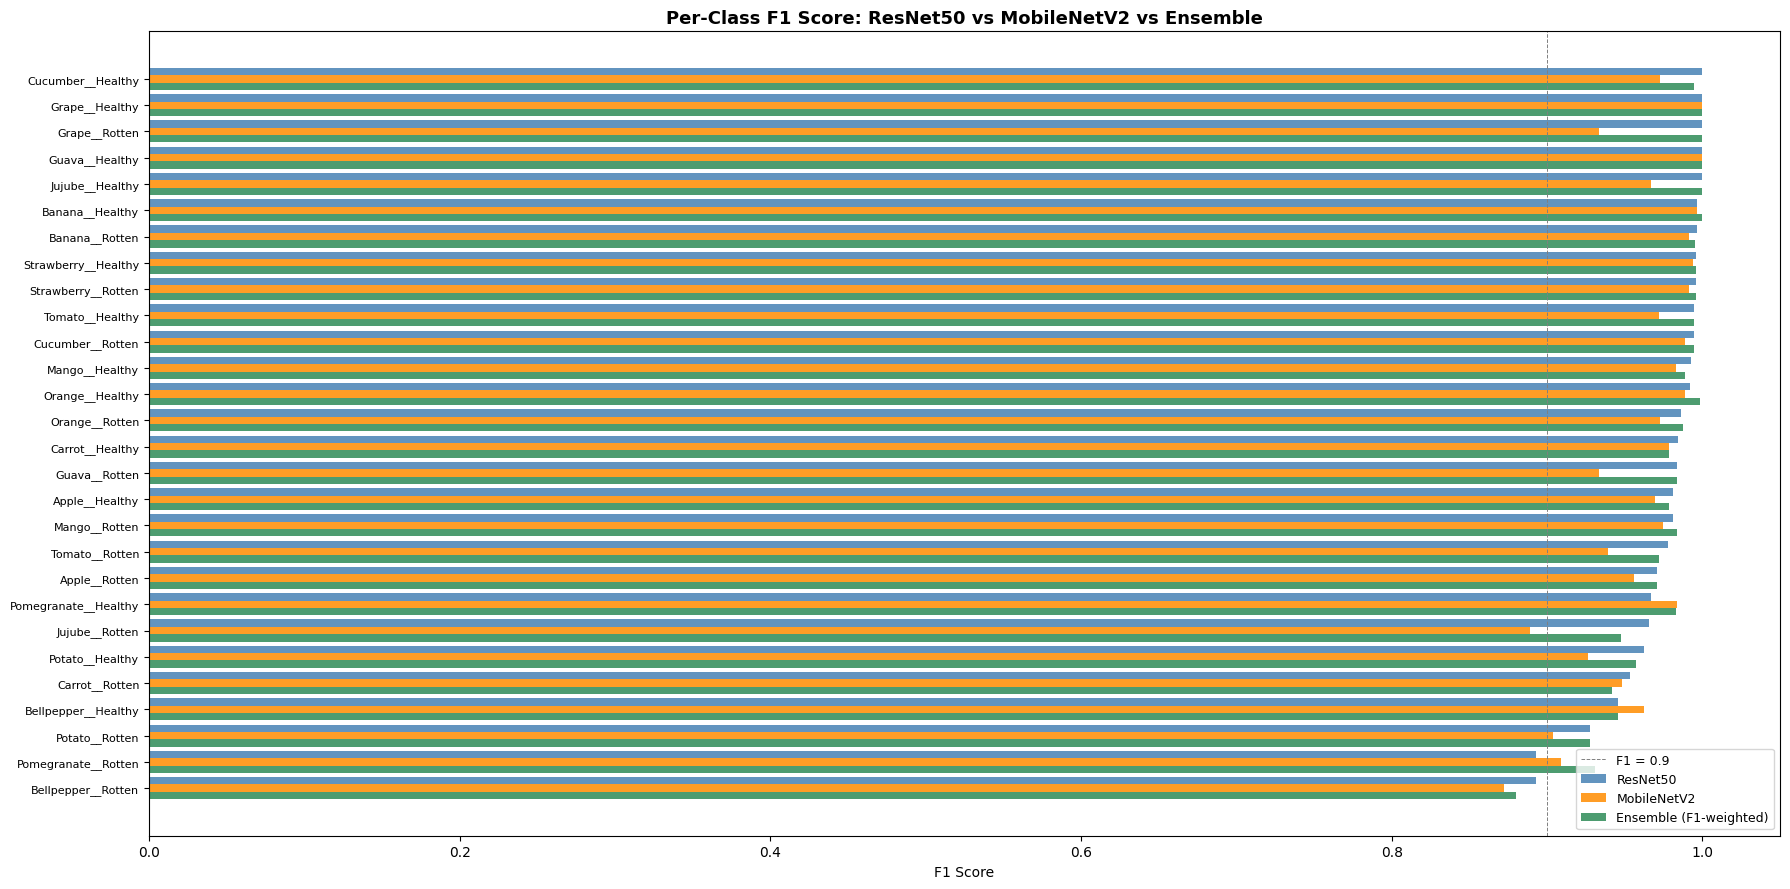

Per-class F1 comparison chart saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/ensemble/per_class_f1_comparison.png


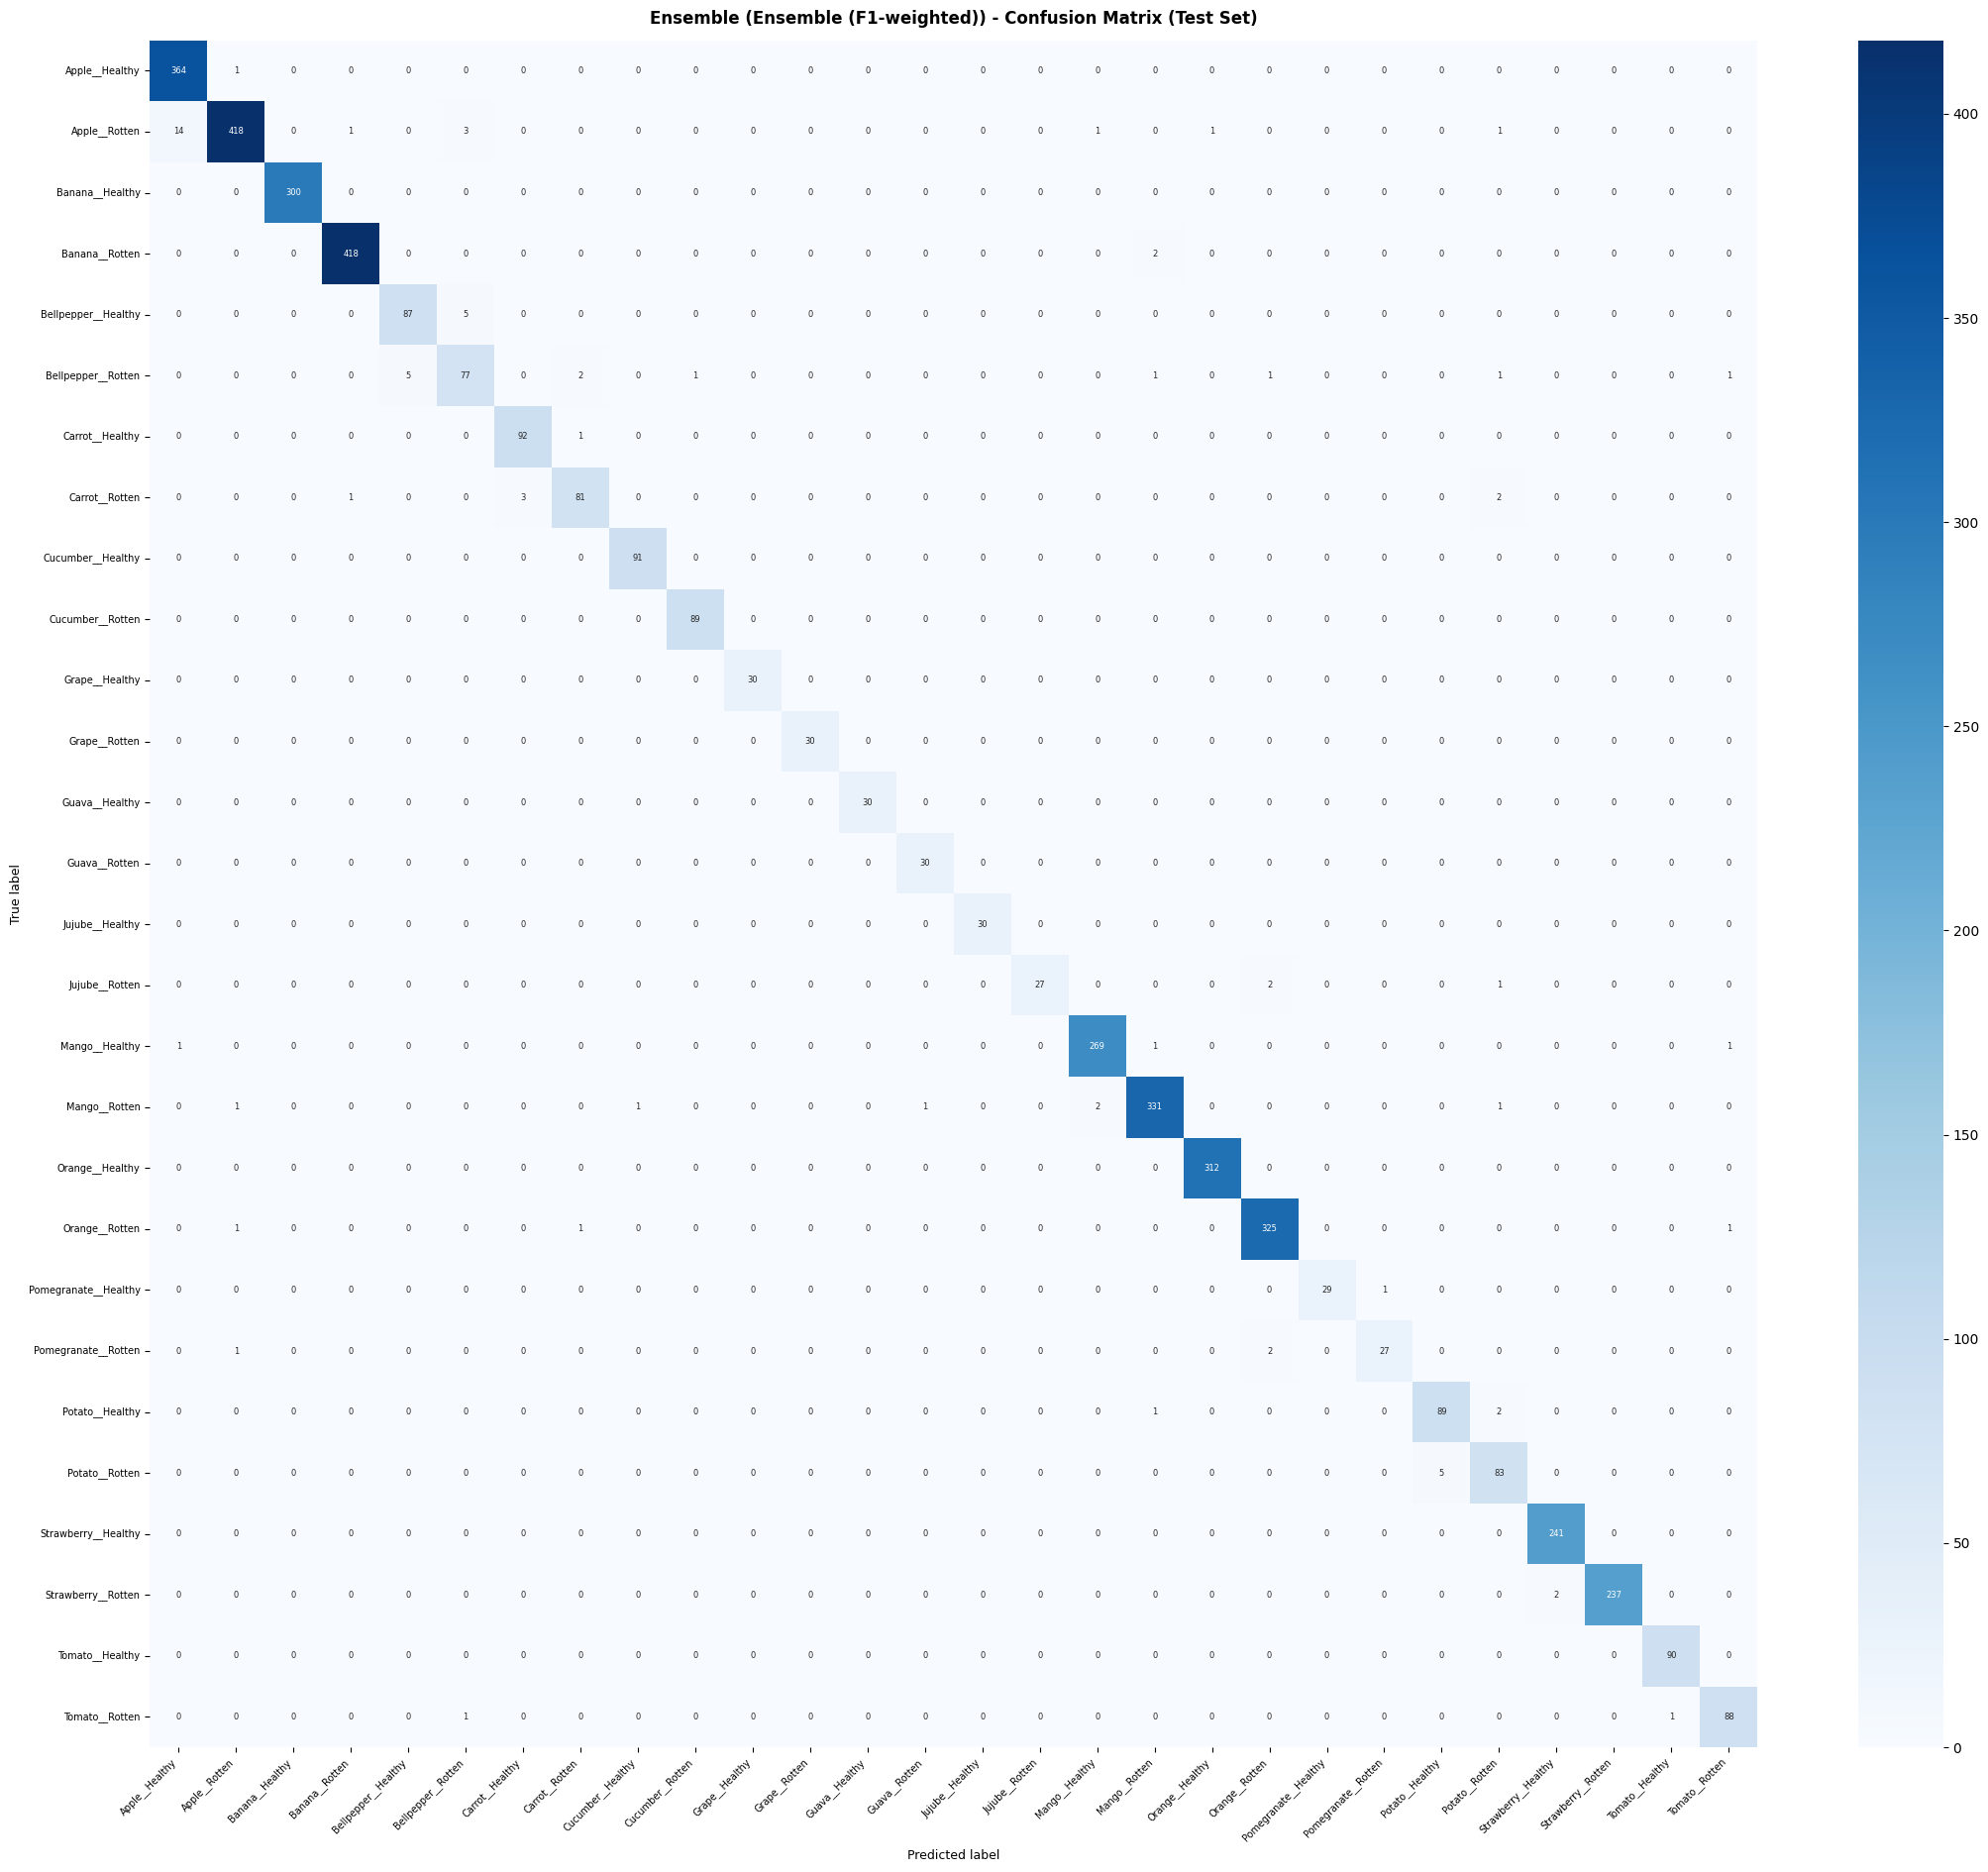

Confusion matrix saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/ensemble/ensemble_confusion_matrix.png


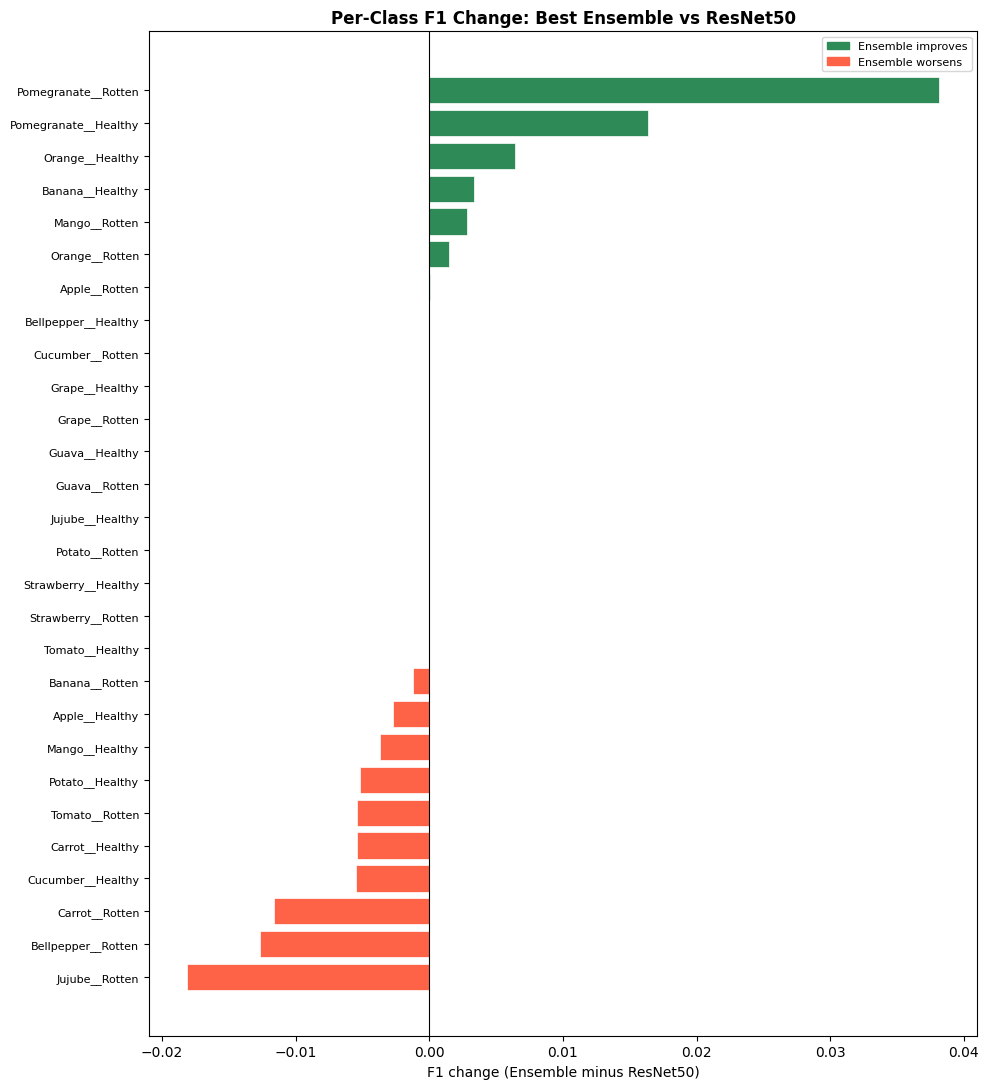

Delta chart saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/ensemble/ensemble_vs_resnet_f1_delta.png

Classes where ensemble improves on ResNet50 (delta > 0):
  Pomegranate__Rotten                 +0.0382
  Pomegranate__Healthy                +0.0164
  Orange__Healthy                     +0.0064
  Banana__Healthy                     +0.0033
  Mango__Rotten                       +0.0029
  Orange__Rotten                      +0.0015

Classes where ensemble worsens relative to ResNet50 (delta < 0):
  Banana__Rotten                      -0.0012
  Apple__Healthy                      -0.0027
  Mango__Healthy                      -0.0037
  Potato__Healthy                     -0.0052
  Tomato__Rotten                      -0.0054
  Carrot__Healthy                     -0.0054
  Cucumber__Healthy                   -0.0055
  Carrot__Rotten                      -0.0116
  Bellpepper__Rotten                  -0.0127
  Jujube__Rotten                      -0.0181


In [11]:
# -- Summary comparison table -------------------------------------------------
print('=' * 72)
print(f'  {"Model":<35} {"Accuracy":>9} {"Macro F1":>9} {"Macro AUC":>10}')
print('  ' + '-' * 68)
for _m in [metrics_resnet, metrics_mobilenet, metrics_equal, metrics_weighted]:
    print(f'  {_m["label"]:<35} {_m["accuracy"]:>9.4f} '
          f'{_m["macro_f1"]:>9.4f} {_m["macro_auc"]:>10.4f}')
print('=' * 72)

# Determine the better ensemble variant for charts.
_best_ensemble = metrics_weighted if metrics_weighted['macro_f1'] >= metrics_equal['macro_f1'] \
                 else metrics_equal
_best_ens_probs = test_probs_weighted if _best_ensemble is metrics_weighted \
                  else test_probs_equal
_best_ens_pred  = test_pred_weighted if _best_ensemble is metrics_weighted \
                  else test_pred_equal
print(f'\nBest ensemble variant: {_best_ensemble["label"]}')

# -- Per-class F1 comparison chart --------------------------------------------
_sorted_classes = sorted(class_names,
                          key=lambda c: metrics_resnet['per_class_f1'][c],
                          reverse=True)
_f1_r   = [metrics_resnet['per_class_f1'][c]    for c in _sorted_classes]
_f1_m   = [metrics_mobilenet['per_class_f1'][c] for c in _sorted_classes]
_f1_ens = [_best_ensemble['per_class_f1'][c]    for c in _sorted_classes]

_x = np.arange(len(_sorted_classes))
_w = 0.28
_fig, _ax = plt.subplots(figsize=(18, 9))
_ax.barh(_x - _w, _f1_r,   _w, label='ResNet50',             color='steelblue',  alpha=0.85)
_ax.barh(_x,      _f1_m,   _w, label='MobileNetV2',          color='darkorange',  alpha=0.85)
_ax.barh(_x + _w, _f1_ens, _w, label=_best_ensemble['label'], color='seagreen',   alpha=0.85)
_ax.set_yticks(_x)
_ax.set_yticklabels(_sorted_classes, fontsize=8)
_ax.set_xlabel('F1 Score')
_ax.set_xlim(0, 1.05)
_ax.invert_yaxis()
_ax.axvline(0.9, color='gray', linestyle='--', linewidth=0.7, label='F1 = 0.9')
_ax.set_title('Per-Class F1 Score: ResNet50 vs MobileNetV2 vs Ensemble',
               fontsize=13, fontweight='bold')
_ax.legend(fontsize=9)
plt.tight_layout()
_f1_chart_path = OUTPUT_DIR / 'per_class_f1_comparison.png'
plt.savefig(str(_f1_chart_path), dpi=120, bbox_inches='tight')
plt.show()
print(f'Per-class F1 comparison chart saved to {_f1_chart_path}')

# -- Ensemble confusion matrix ------------------------------------------------
_cm = confusion_matrix(test_true_idx, _best_ens_pred)
_cm_path = OUTPUT_DIR / 'ensemble_confusion_matrix.png'
_fig, _ax = plt.subplots(figsize=(22, 19))
sns.heatmap(
    _cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=_ax, annot_kws={'size': 6}
)
_ax.set_xticklabels(_ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
_ax.set_yticklabels(_ax.get_yticklabels(), rotation=0, fontsize=7)
_ax.set_xlabel('Predicted label', fontsize=9)
_ax.set_ylabel('True label', fontsize=9)
_ax.set_title(f'Ensemble ({_best_ensemble["label"]}) - Confusion Matrix (Test Set)',
               fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(str(_cm_path), dpi=120, bbox_inches='tight')
plt.show()
print(f'Confusion matrix saved to {_cm_path}')

# -- Per-class delta: ensemble vs best individual model ----------------------
# Compare ensemble F1 against ResNet50 (the stronger individual model) per class.
_delta = {c: _best_ensemble['per_class_f1'][c] - metrics_resnet['per_class_f1'][c]
          for c in class_names}
_sorted_delta = sorted(_delta.items(), key=lambda x: x[1], reverse=True)
_delta_cls    = [x[0] for x in _sorted_delta]
_delta_vals   = [x[1] for x in _sorted_delta]
_delta_cols   = ['seagreen' if v >= 0 else 'tomato' for v in _delta_vals]

_delta_path = OUTPUT_DIR / 'ensemble_vs_resnet_f1_delta.png'
_fig, _ax   = plt.subplots(figsize=(10, 11))
_ax.barh(_delta_cls, _delta_vals, color=_delta_cols, edgecolor='white', linewidth=0.5)
_ax.axvline(0, color='black', linewidth=0.8)
_ax.set_xlabel('F1 change (Ensemble minus ResNet50)')
_ax.invert_yaxis()
_ax.set_title('Per-Class F1 Change: Best Ensemble vs ResNet50',
               fontsize=12, fontweight='bold')
_ax.tick_params(axis='y', labelsize=8)
_green_patch = mpatches.Patch(color='seagreen', label='Ensemble improves')
_red_patch   = mpatches.Patch(color='tomato',   label='Ensemble worsens')
_ax.legend(handles=[_green_patch, _red_patch], fontsize=8)
plt.tight_layout()
plt.savefig(str(_delta_path), dpi=120, bbox_inches='tight')
plt.show()
print(f'Delta chart saved to {_delta_path}')

# Print classes where ensemble improved or worsened.
print()
print('Classes where ensemble improves on ResNet50 (delta > 0):')
for _c, _d in _sorted_delta:
    if _d > 0.0001:
        print(f'  {_c:<35} +{_d:.4f}')
print()
print('Classes where ensemble worsens relative to ResNet50 (delta < 0):')
for _c, _d in _sorted_delta:
    if _d < -0.0001:
        print(f'  {_c:<35} {_d:.4f}')

## Section 9   OpenCV Quality Scoring Pipeline

Defines and tests the full quality scoring pipeline. Given an image path, `grade_image` runs the F1-weighted ensemble to identify produce type and quality, then computes the three sub-scores:

- **Colour %** — `compute_colour_score`: HS histogram correlation against the healthy reference for the identified produce type, mapped from [-1, 1] to [0, 100].
- **Size %** — `compute_size_score`: largest-contour area divided by the median healthy bounding box area, capped at 100%.
- **Ripeness %** — `compute_ripeness_score`: `0.5 × Colour + 0.2 × Size + 0.3 × Quality`, where Quality is the ensemble's confidence in the Healthy class.

Grade thresholds are applied by `assign_grade` to produce Grade A, B, or C.

In [18]:
def load_and_preprocess_for_inference(image_path):
    """Load an image from disk and return two normalised tensors -- one for each model.

    Returns a tuple (resnet_input, mobilenet_input) each of shape (1, 224, 224, 3).
    PIL is used for loading to handle all file formats including .webp and RGBA.
    """
    img_pil = Image.open(str(image_path)).convert('RGB')
    img_arr = np.array(img_pil, dtype=np.float32)

    # Resize shorter edge to IMG_SIZE, preserving aspect ratio.
    h, w = img_arr.shape[:2]
    if w <= h:
        new_w = IMG_SIZE
        new_h = int(round(h * IMG_SIZE / w))
    else:
        new_h = IMG_SIZE
        new_w = int(round(w * IMG_SIZE / h))
    img_resized = np.array(
        img_pil.resize((new_w, new_h), Image.LANCZOS), dtype=np.float32
    )

    # Centre-crop to 224x224.
    off_h = (new_h - IMG_SIZE) // 2
    off_w = (new_w - IMG_SIZE) // 2
    img_crop = img_resized[off_h:off_h + IMG_SIZE, off_w:off_w + IMG_SIZE]

    img_batch = img_crop[np.newaxis, ...]   # shape (1, 224, 224, 3)

    resnet_input    = tf.keras.applications.resnet50.preprocess_input(img_batch.copy())
    mobilenet_input = tf.keras.applications.mobilenet_v2.preprocess_input(img_batch.copy())

    return resnet_input, mobilenet_input


def compute_colour_score(image_path, produce_type):
    """Compute Colour % for an image relative to the healthy reference for its produce type.

    Uses HS histogram correlation. A score of 1.0 means the image's colour
    distribution is identical to the healthy reference; 0.0 means no overlap.

    Returns a float in [0, 100].
    """
    try:
        img_pil = Image.open(str(image_path)).convert('RGB')
        img_bgr = cv2.cvtColor(np.array(img_pil, dtype=np.uint8), cv2.COLOR_RGB2BGR)
    except Exception:
        return 50.0   # neutral fallback on load error

    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist    = cv2.calcHist(
        [img_hsv], [0, 1], None,
        [HSV_BINS[0], HSV_BINS[1]],
        [0, 180, 0, 256]
    )
    cv2.normalize(hist, hist, 0, 1, cv2.NORM_MINMAX)

    ref = colour_refs.get(produce_type)
    if ref is None:
        return 50.0

    # Histogram correlation: ranges from -1 (inverse) to 1 (identical).
    # Correlation between two normalised histograms is robust to scale and
    # does not require manual normalisation of the intersection result.
    # ref is loaded from JSON as float64; compareHist requires float32.
    correlation = float(cv2.compareHist(hist, ref.astype(np.float32), cv2.HISTCMP_CORREL))

    # Map from [-1, 1] to [0, 100]: a perfect match gives 100%, no
    # correlation gives 50%, inverse correlation gives 0%.
    colour_score = max((correlation + 1.0) / 2.0 * 100.0, 0.0)
    return round(colour_score, 1)


def compute_size_score(image_path, produce_type):
    """Compute Size % for an image relative to the median healthy bounding box for its produce type.

    Detects the largest foreground contour and compares its area to the
    reference median area. Scores above 100% are capped at 100.

    Returns a float in [0, 100].
    """
    try:
        img_pil = Image.open(str(image_path)).convert('RGB')
        img_bgr = cv2.cvtColor(np.array(img_pil, dtype=np.uint8), cv2.COLOR_RGB2BGR)
    except Exception:
        return 50.0

    img_area = img_bgr.shape[0] * img_bgr.shape[1]
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = [c for c in contours if cv2.contourArea(c) > MIN_CONTOUR_FRAC * img_area]

    if valid:
        detected_area = cv2.contourArea(max(valid, key=cv2.contourArea))
    else:
        detected_area = img_area * 0.5   # fallback if no contour detected

    ref_area = size_refs.get(produce_type, img_area * 0.5)
    size_score = min(detected_area / ref_area, 1.0) * 100.0 if ref_area > 0 else 50.0
    return round(size_score, 1)

def compute_ripeness_score(colour_pct, size_pct, quality, confidence):
    """Compute Ripeness % from colour, size, and model quality classification.

    Ripeness = 0.5 * Colour % + 0.2 * Size % + 0.3 * Quality %

    Quality % reflects the model's confidence in the Healthy classification:
        Healthy prediction: Quality % = confidence * 100
        Rotten  prediction: Quality % = (1 - confidence) * 100

    This formula treats ripeness as a composite of visual appearance (colour
    and size) and predicted quality state. A confidently rotten prediction
    contributes 0 to the Quality component, capping ripeness at 70% even
    for visually healthy-looking rotten produce, which prevents Grade A
    assignment. A confidently healthy prediction contributes 30 points,
    allowing Grade A when colour and size are also strong.

    Returns a float in [0, 100].
    """
    if quality == 'Healthy':
        quality_score = confidence * 100.0
    else:
        quality_score = (1.0 - confidence) * 100.0
    ripeness = 0.5 * colour_pct + 0.2 * size_pct + 0.3 * quality_score
    return round(ripeness, 1)

def assign_grade(colour_pct, size_pct, ripeness_pct):
    """Assign an overall grade based on the case study threshold specification.

    Grade A: Colour >= 75%, Size >= 80%, Ripeness >= 70%
    Grade B: Colour >= 65%, Size >= 70%, Ripeness >= 60%
    Grade C: below Grade B on any metric

    Returns 'A', 'B', or 'C'.
    """
    if (colour_pct >= GRADE_A['colour'] and
            size_pct >= GRADE_A['size'] and
            ripeness_pct >= GRADE_A['ripeness']):
        return 'A'
    elif (colour_pct >= GRADE_B['colour'] and
              size_pct >= GRADE_B['size'] and
              ripeness_pct >= GRADE_B['ripeness']):
        return 'B'
    else:
        return 'C'


def grade_image(image_path):
    """Run the full quality assessment pipeline on a single image.

    Parameters
    ----------
    image_path : str or Path
        Path to the image file.

    Returns
    -------
    dict with keys:
        predicted_class, produce_type, quality, confidence,
        colour_pct, size_pct, ripeness_pct, grade, prob_vector
    """
    # -- Ensemble inference ---------------------------------------------------
    resnet_input, mobilenet_input = load_and_preprocess_for_inference(image_path)
    probs_r = resnet_model(resnet_input,       training=False).numpy()[0]
    probs_m = mobilenet_model(mobilenet_input, training=False).numpy()[0]
    prob_vec = W_RESNET * probs_r + W_MOBILENET * probs_m

    pred_idx   = int(np.argmax(prob_vec))
    pred_name  = class_names[pred_idx]
    confidence = float(prob_vec[pred_idx])
    produce    = class_name_to_produce(pred_name)
    quality    = class_name_to_quality(pred_name)

    # -- Sub-scores -----------------------------------------------------------
    colour_pct   = compute_colour_score(image_path, produce)
    size_pct     = compute_size_score(image_path, produce)
    ripeness_pct = compute_ripeness_score(colour_pct, size_pct, quality, confidence)
    grade        = assign_grade(colour_pct, size_pct, ripeness_pct)

    return {
        'predicted_class': pred_name,
        'produce_type'   : produce,
        'quality'        : quality,
        'confidence'     : round(confidence, 4),
        'colour_pct'     : colour_pct,
        'size_pct'       : size_pct,
        'ripeness_pct'   : ripeness_pct,
        'grade'          : grade,
        'prob_vector'    : prob_vec.tolist(),
    }


print('OpenCV grading pipeline functions defined.')
print('  grade_image(image_path) -> dict with predicted_class, colour_pct, size_pct, ripeness_pct, grade')

OpenCV grading pipeline functions defined.
  grade_image(image_path) -> dict with predicted_class, colour_pct, size_pct, ripeness_pct, grade


## Section 10   Demo Grading on Sample Images

Demonstrates the full grading pipeline on eight test set images — one Healthy and one Rotten from each of four produce types (Apple, Banana, Tomato, Jujube).

Running full grading pipeline on demo images...

  Apple__Healthy
    Predicted : Apple__Healthy  (confidence 1.000)
    Colour    : 94.8%
    Size      : 100.0%
    Ripeness  : 97.4%
    Grade     : A

  Apple__Rotten
    Predicted : Apple__Rotten  (confidence 1.000)
    Colour    : 91.4%
    Size      : 88.9%
    Ripeness  : 63.5%
    Grade     : B

  Banana__Healthy
    Predicted : Banana__Healthy  (confidence 1.000)
    Colour    : 56.3%
    Size      : 100.0%
    Ripeness  : 78.1%
    Grade     : C

  Banana__Rotten
    Predicted : Banana__Rotten  (confidence 1.000)
    Colour    : 84.5%
    Size      : 67.5%
    Ripeness  : 55.8%
    Grade     : C

  Tomato__Healthy
    Predicted : Tomato__Healthy  (confidence 1.000)
    Colour    : 82.1%
    Size      : 100.0%
    Ripeness  : 91.0%
    Grade     : A

  Tomato__Rotten
    Predicted : Tomato__Rotten  (confidence 1.000)
    Colour    : 62.2%
    Size      : 32.4%
    Ripeness  : 37.6%
    Grade     : C

  Jujube__Healthy
    Predic

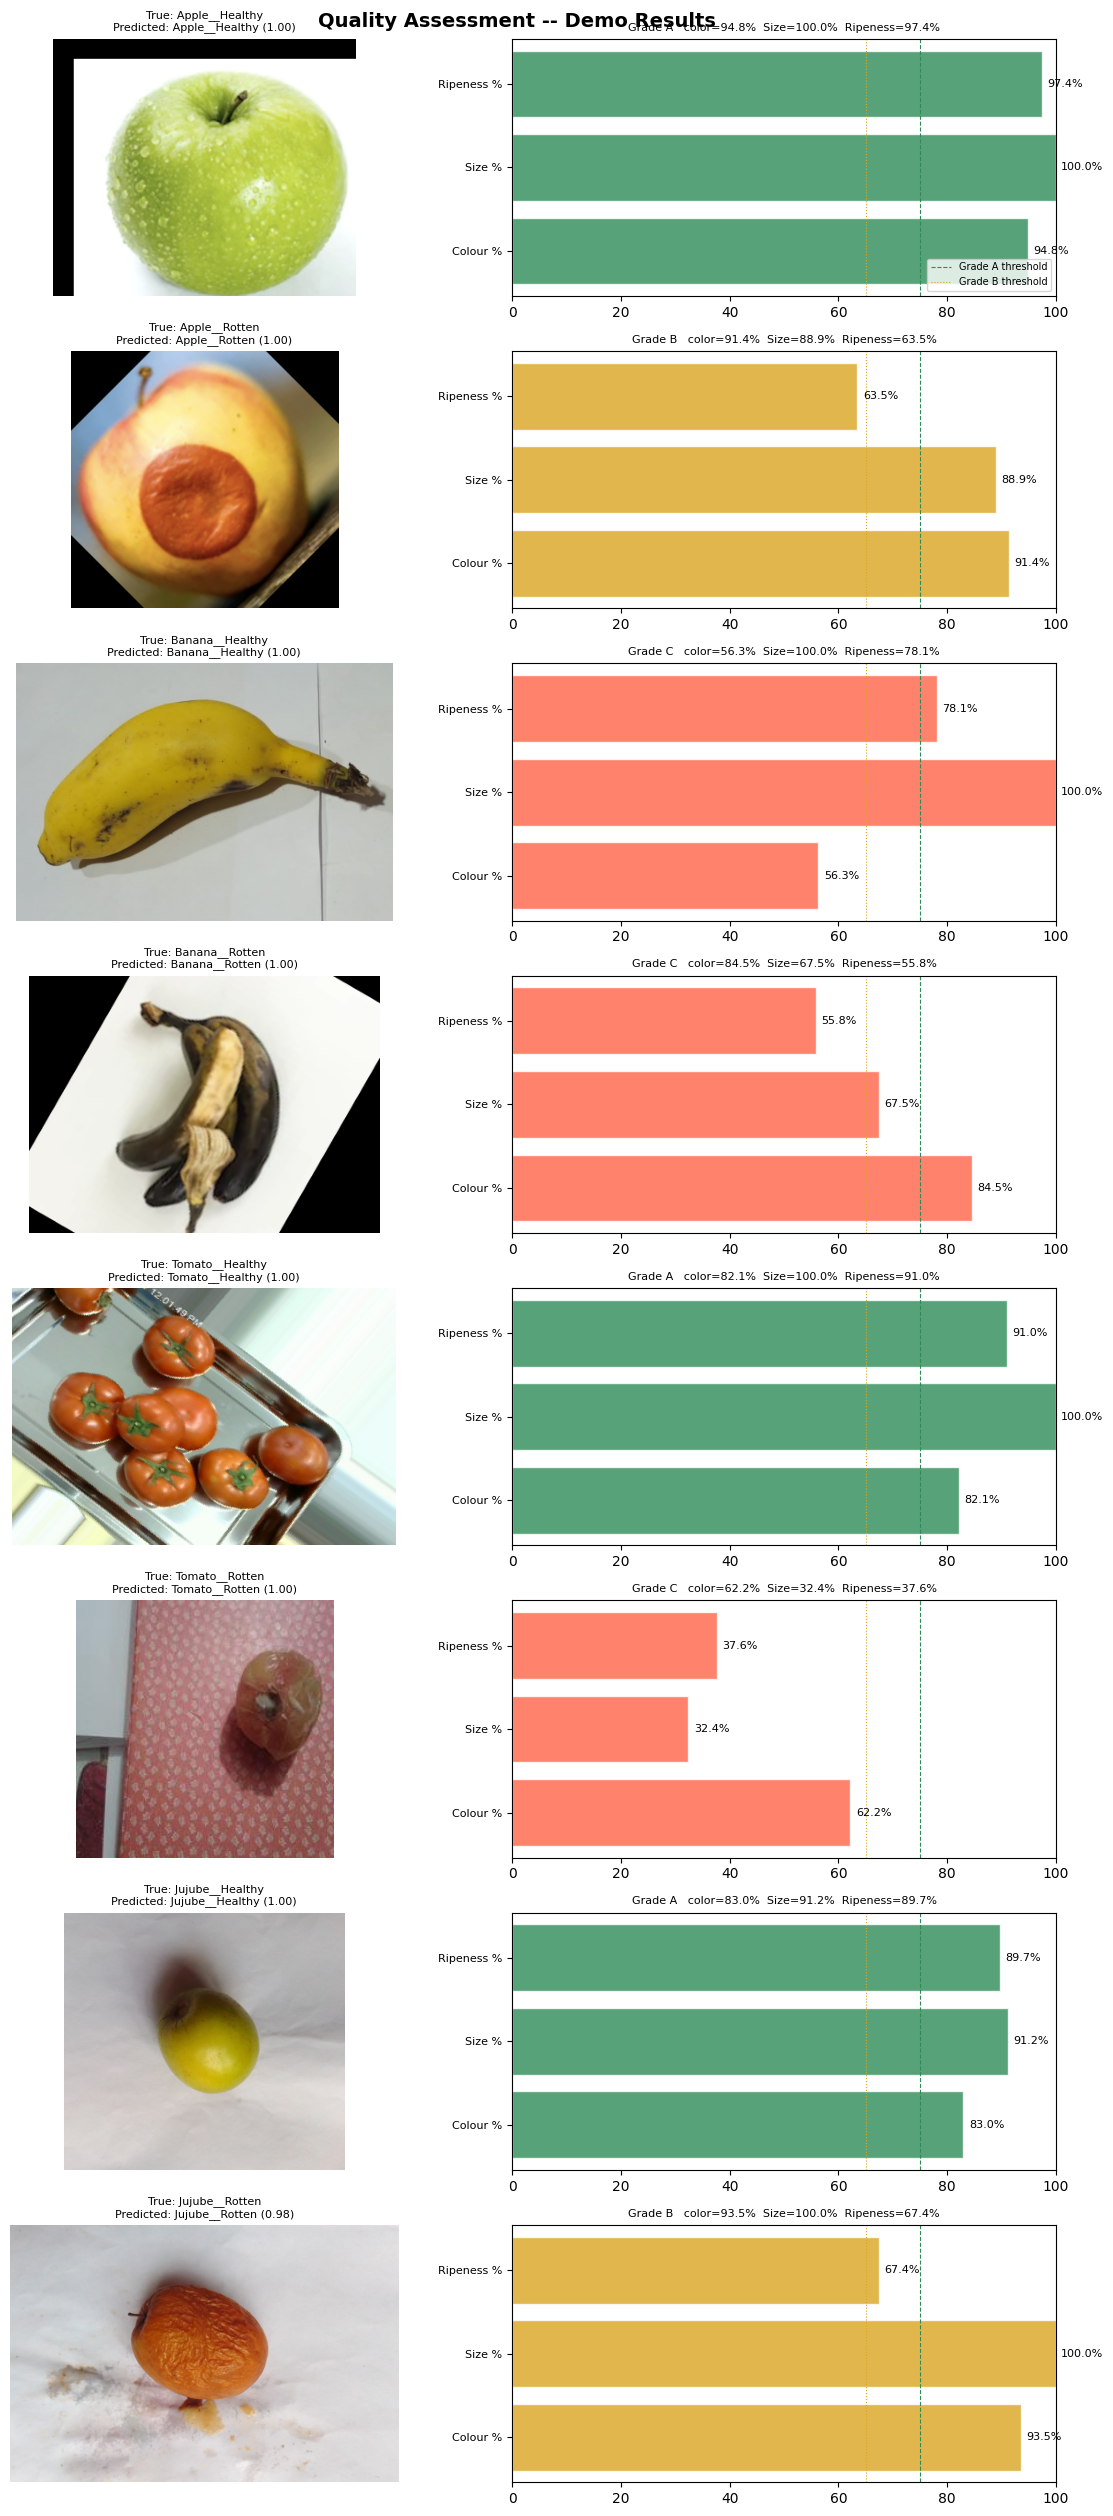

Demo grading chart saved to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/ensemble/grading_demo.png


In [19]:
# Select 8 representative test images: one Healthy and one Rotten from
# four different produce types, chosen to span the range of grades.
DEMO_CLASSES = [
    'Apple__Healthy',   'Apple__Rotten',
    'Banana__Healthy',  'Banana__Rotten',
    'Tomato__Healthy',  'Tomato__Rotten',
    'Jujube__Healthy',  'Jujube__Rotten',
]

# Find one test image per demo class.
_class_to_test_files = {}
for _fp, _li in test_samples:
    _cn = index_to_class[_li]
    if _cn in DEMO_CLASSES and _cn not in _class_to_test_files:
        _class_to_test_files[_cn] = str(_fp)

print('Running full grading pipeline on demo images...')
print()

_demo_results = []
for _cls in DEMO_CLASSES:
    if _cls not in _class_to_test_files:
        print(f'  {_cls}: no test image found, skipping.')
        continue
    _fp     = _class_to_test_files[_cls]
    _result = grade_image(_fp)
    _result['image_path']  = _fp
    _result['true_class']  = _cls
    _demo_results.append(_result)
    print(f'  {_cls}')
    print(f'    Predicted : {_result["predicted_class"]}  (confidence {_result["confidence"]:.3f})')
    print(f'    Colour    : {_result["colour_pct"]}%')
    print(f'    Size      : {_result["size_pct"]}%')
    print(f'    Ripeness  : {_result["ripeness_pct"]}%')
    print(f'    Grade     : {_result["grade"]}')
    print()

# -- Visualisation ------------------------------------------------------------
_n = len(_demo_results)
_fig, _axes = plt.subplots(_n, 2, figsize=(12, _n * 3.2))
_fig.suptitle('Quality Assessment -- Demo Results', fontsize=14, fontweight='bold')

_grade_colours = {'A': 'seagreen', 'B': 'goldenrod', 'C': 'tomato'}

for _row, _res in enumerate(_demo_results):
    _img_pil = Image.open(_res['image_path']).convert('RGB')
    _ax_img  = _axes[_row][0]
    _ax_bar  = _axes[_row][1]

    # Image panel.
    _ax_img.imshow(_img_pil)
    _ax_img.axis('off')
    _ax_img.set_title(
        f'True: {_res["true_class"]}\nPredicted: {_res["predicted_class"]} '
        f'({_res["confidence"]:.2f})',
        fontsize=8
    )

    # Sub-score bar chart panel.
    _scores = [_res['colour_pct'], _res['size_pct'], _res['ripeness_pct']]
    _labels = ['Colour %', 'Size %', 'Ripeness %']
    _gcol   = _grade_colours[_res['grade']]
    _bars   = _ax_bar.barh(_labels, _scores, color=_gcol, alpha=0.8, edgecolor='white')
    _ax_bar.set_xlim(0, 100)
    _ax_bar.axvline(GRADE_A['colour'], color='seagreen',  linestyle='--',
                    linewidth=0.8, label='Grade A threshold')
    _ax_bar.axvline(GRADE_B['colour'], color='goldenrod', linestyle=':',
                    linewidth=0.8, label='Grade B threshold')
    _ax_bar.set_title(f'Grade {_res["grade"]}   '
                       f'color={_res["colour_pct"]}%  '
                       f'Size={_res["size_pct"]}%  '
                       f'Ripeness={_res["ripeness_pct"]}%',
                       fontsize=8)
    _ax_bar.tick_params(axis='y', labelsize=8)
    if _row == 0:
        _ax_bar.legend(fontsize=7, loc='lower right')

    # Annotate bars with values.
    for _bar, _val in zip(_bars, _scores):
        _ax_bar.text(_val + 1, _bar.get_y() + _bar.get_height() / 2,
                     f'{_val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
_demo_path = OUTPUT_DIR / 'grading_demo.png'
plt.savefig(str(_demo_path), dpi=120, bbox_inches='tight')
plt.show()
print(f'Demo grading chart saved to {_demo_path}')

## Section 11   Summary

This section always runs regardless of earlier cell state. It loads the ensemble metrics from disk (if available) and prints the final comparison table and the status of all output files.

In [20]:
print('=' * 72)
print('  Ensemble Evaluation and OpenCV Grading Summary')
print('=' * 72)

if ENSEMBLE_METRICS_PATH.exists():
    with open(ENSEMBLE_METRICS_PATH, 'r', encoding='utf-8') as fh:
        _saved = json.load(fh)

    print()
    print('Ensemble weights (derived from validation macro-F1):')
    print(f'  w_resnet50    = {_saved["ensemble_weights"]["resnet50"]:.4f}')
    print(f'  w_mobilenetv2 = {_saved["ensemble_weights"]["mobilenetv2"]:.4f}')

    print()
    print(f'  {"Model":<35} {"Accuracy":>9} {"Macro F1":>9} {"Macro AUC":>10}')
    print('  ' + '-' * 68)
    for _key in ['resnet50_individual', 'mobilenetv2_individual',
                  'ensemble_equal_weight', 'ensemble_f1_weighted']:
        _m = _saved[_key]
        print(f'  {_m["label"]:<35} {_m["accuracy"]:>9.4f} '
              f'{_m["macro_f1"]:>9.4f} {_m["macro_auc"]:>10.4f}')
else:
    print('Metrics not yet available -- run Section 7 first.')

print()
print('Output files:')
_outputs = [
    ('Ensemble metrics JSON',         ENSEMBLE_METRICS_PATH),
    ('Colour references',              COLOUR_REF_PATH),
    ('Size references',                SIZE_REF_PATH),
    ('Per-class F1 comparison chart',  OUTPUT_DIR / 'per_class_f1_comparison.png'),
    ('Ensemble confusion matrix',      OUTPUT_DIR / 'ensemble_confusion_matrix.png'),
    ('Ensemble vs ResNet50 delta',     OUTPUT_DIR / 'ensemble_vs_resnet_f1_delta.png'),
    ('Grading demo chart',             OUTPUT_DIR / 'grading_demo.png'),
]
for _label, _path in _outputs:
    _status = 'exists' if _path.exists() else 'not yet created'
    print(f'  {_label:<35} {_status:<18} {_path.name}')

  Ensemble Evaluation and OpenCV Grading Summary

Ensemble weights (derived from validation macro-F1):
  w_resnet50    = 0.5026
  w_mobilenetv2 = 0.4974

  Model                                Accuracy  Macro F1  Macro AUC
  --------------------------------------------------------------------
  ResNet50 (individual)                  0.9822    0.9760     0.9999
  MobileNetV2 (individual)               0.9720    0.9607     0.9997
  Ensemble (equal weight)                0.9820    0.9760     0.9999
  Ensemble (F1-weighted)                 0.9820    0.9760     0.9999

Output files:
  Ensemble metrics JSON               exists             ensemble_metrics.json
  Colour references                   exists             colour_references.json
  Size references                     exists             size_references.json
  Per-class F1 comparison chart       exists             per_class_f1_comparison.png
  Ensemble confusion matrix           exists             ensemble_confusion_matrix.png
  Ense